# Laboratorio 5: Modelos en PyTorch
## Parte 2: Regresión Logística Binaria (Clasificación)
En esta segunda libreta entrenaremos un dataset utilizando Regresión Logística (Binaria). Usaremos el dataset de "Buzz in Social Media" para determinar si un tema será popular o no (Clase 1 o Clase 0).

In [1]:
# IMPORTANTE: Si estás ejecutando este cuadernillo en Google Colab,
# descomenta y ejecuta estas líneas para montar tu Google Drive.
from google.colab import drive
drive.mount('/content/drive')

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

Mounted at /content/drive
Usando dispositivo: cuda


### 2.1 Preprocesamiento: Tarea continua a Clasificación Binaria
Convertiremos el objetivo continuo (promedio de discusiones) en 0 y 1 para predecir Popularidad.

In [2]:
# Ruta del archivo de datos de Twitter (Buzz in Social Media)
archivo_buzz = '/content/drive/MyDrive/LABSIS420/Twitter.data'

# Cargamos el archivo CSV a un DataFrame de Pandas (header=None porque no tiene nombres de columnas)
df_buzz = pd.read_csv(archivo_buzz, header=None)

# Separamos X (características): Elegimos todas las filas (:) y todas las columnas excepto la última (:-1)
X_buzz_pandas = df_buzz.iloc[:, :-1].values

# Separamos Y (la respuesta real original en formato continuo): Elegimos la última columna (-1)
Y_buzz_pandas_raw = df_buzz.iloc[:, -1].values

# Calculamos el promedio de discusiones (umbral) de toda la última columna
umbral = Y_buzz_pandas_raw.mean()

# "Convertimos a problema Binario": Todo el que esté arriba del promedio es 1 (Popular), si está abajo es 0 (No popular)
# .astype(int) convierte los resultados True/False en 1s y 0s
Y_buzz_clases = (Y_buzz_pandas_raw > umbral).astype(int)

# Obtenemos la cantidad total de filas (m)
m = len(Y_buzz_clases)

# Imprimimos resultados para ver las dimensiones
print(f"Total de ejemplos (m): {m} ")
print(f"Total de propiedades (n): {X_buzz_pandas.shape[1]} ")

# Contamos cuántos ceros y unos existen para asegurarnos de que se dividió bien
unicos, conteos = np.unique(Y_buzz_clases, return_counts=True)
print(f"Clase 0 (No Popular): {conteos[0]}")
print(f"Clase 1 (Popular): {conteos[1]}")

Total de ejemplos (m): 583250 
Total de propiedades (n): 77 
Clase 0 (No Popular): 461873
Clase 1 (Popular): 121377


### 2.2 Separación del 80/20, Normalización y Dataset

In [3]:
# Calculamos el número de fila que representa el 80% (Para Entrenamiento)
limite_buzz = int(0.8 * m)

# ---- Separación 80 Train / 20 Test ----
# X (Características)
X_train_buzz_raw = X_buzz_pandas[:limite_buzz] # Tomamos desde el principio hasta el 80%
X_test_buzz_raw = X_buzz_pandas[limite_buzz:]  # Tomamos desde el 80% hasta el final

# Y (Etiquetas/Clases 0 o 1)
Y_train_buzz = Y_buzz_clases[:limite_buzz] # Entrenamiento
Y_test_buzz = Y_buzz_clases[limite_buzz:]  # Pruebas

# ---- Normalización Z-Score de los datos de entrada (X) ----
# Calculamos la media de las características (solo con datos de entrenamiento para no hacer trampa)
X_mean_buzz = X_train_buzz_raw.mean(axis=0)
# Calculamos la desviación estándar (+ 1e-8 evita división entre cero)
X_std_buzz = X_train_buzz_raw.std(axis=0) + 1e-8

# Estandarizamos (Restar media y dividir por std) esto acelera y ayuda al aprendizaje de la red neuronal
X_train_buzz = (X_train_buzz_raw - X_mean_buzz) / X_std_buzz
X_test_buzz = (X_test_buzz_raw - X_mean_buzz) / X_std_buzz

# ---- Reformateo y tipado para que PyTorch no genere errores -----
# Convertimos Y a columna (.reshape(-1, 1)) y a formato float32 requerido por PyTorch para regresión/binaria
y_train_buzz = Y_train_buzz.astype(np.float32).reshape(-1, 1)
y_test_buzz = Y_test_buzz.astype(np.float32).reshape(-1, 1)

# Aseguramos de que las características también sean formato float32
X_train_buzz = X_train_buzz.astype(np.float32)
X_test_buzz = X_test_buzz.astype(np.float32)

# ---- Creación de Dataloaders (Gestor Automático de lotes de PyTorch) ----
class DatasetBinario(torch.utils.data.Dataset):
    def __init__(self, X, Y):
        # Al instanciar, convierte los arrays de Numpy en Tensores de Pytorch y los envía a la GPU de inmediato
        self.X = torch.from_numpy(X).float().to(device)
        self.Y = torch.from_numpy(Y).float().to(device)

    def __len__(self):
        # Retorna el tamaño total de los datos
        return len(self.X)

    def __getitem__(self, ix):
        # Permite acceder a una fila específica X y su Y correspondiente con dataloader[ix]
        return self.X[ix], self.Y[ix]

# Creamos nuestros conjuntos en formato compatible con DataLoader
dataset_train_bin = DatasetBinario(X_train_buzz, y_train_buzz)
dataset_test_bin = DatasetBinario(X_test_buzz, y_test_buzz)

# Definimos el tamaño del lote (batche de datos) que meteremos a la red simultáneamente
batch_size_bin = 90000

# DataLoader de Entrenamiento (Puesto en "shuffle=True" para mezclar los datos y evitar memorización secuencial)
dataloader_train_bin = torch.utils.data.DataLoader(dataset_train_bin, batch_size=batch_size_bin, shuffle=True)
# DataLoader de Prueba (shuffle=False porque para probar no importa el orden)
dataloader_test_bin = torch.utils.data.DataLoader(dataset_test_bin, batch_size=batch_size_bin, shuffle=False)

print("DataLoaders listos.")

DataLoaders listos.


### 2.3 Diseño de la Red y el Entranamiento
Uso de Función Sigmoide en la última capa para Regresión Logística y `BCELoss`.

Iniciando Entrenamiento (Binario)...
Epoch 50/250 - Costo (BCELoss): 0.10755
Epoch 100/250 - Costo (BCELoss): 0.10019
Epoch 150/250 - Costo (BCELoss): 0.09715
Epoch 200/250 - Costo (BCELoss): 0.09541
Epoch 250/250 - Costo (BCELoss): 0.09420
Modelo guardado exitosamente en: ./checkpoint_clasificacion_binaria.pt


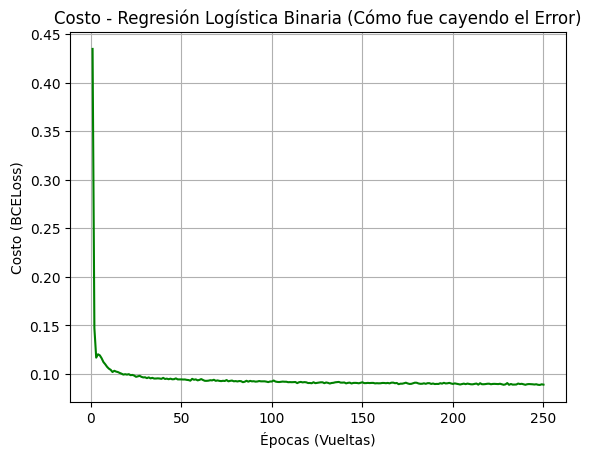

In [4]:
import matplotlib.pyplot as plt

# --- 2.3 Diseño de la Red (Clasificación Binaria) ---
# D_in_bin: Cantidad de entradas. Lo extraemos dinámicamente de 'shape[1]' (las columnas) de nuestro X_train_buzz
D_in_bin = X_train_buzz.shape[1]
# H_bin: Usamos 150 neuronas ocultas. Le damos más capacidad de aprender relaciones complejas.
H_bin = 150
# D_out_bin: Salida = 1. Solo necesitamos una neurona porque responderá 0 (No Popular) o 1 (Popular)
D_out_bin = 1

# Creamos la Red Neuronal
model_bin = torch.nn.Sequential(
    # Capa de Entrada a Capa Oculta
    torch.nn.Linear(D_in_bin, H_bin),
    # Activación ReLU: Transforma números negativos en cero para detectar relaciones no lineales (complejas)
    torch.nn.ReLU(),
    # Capa Oculta hacia Salida final
    torch.nn.Linear(H_bin, D_out_bin),
    # ¡CLAVE!: Función de Activación SIGMOIDE. Comprime cualquier resultado matemático entre un rango de 0 y 1. (Ideal para "Probabilidades")
    torch.nn.Sigmoid()
).to(device) # .to(device) lo ejecuta en GPU (Tarjeta de video) si está disponible para hacerlo rapidísimo

# --- Función de Pérdida (Costo) y Optimizador ---
# BCELoss = Binary Cross Entropy Loss. Es la fórmula matemática oficial en Machine Learning para sistemas que eligen entre "Sí" y "No".
criterion_bin = torch.nn.BCELoss()
# Usamos el optimizador Adam. Ajustará automáticamente los parámetros (pesos) intentando minimizar el error encontrado.
optimizer_bin = torch.optim.Adam(model_bin.parameters(), lr=0.005)

# --- Configuración de Entrenamiento ---
epochs_bin = 250   # 250 vueltas de aprendizaje completo sobre todos los datos
log_each_bin = 50  # Nos informará su progreso cada 50 vueltas
l_bin = []         # Lista donde guardaremos cómo fue evolucionando el error para graficarlo después
model_bin.train()  # Ponemos al modelo en modo "Alumno/Entrenamiento"

print("Iniciando Entrenamiento (Binario)...")
for e in range(1, epochs_bin + 1):
    _l = [] # Lista temporal para guardar el error de pequeños grupitos en esta vuelta

    # Repasamos el iterador de datos en grupos (batches x_b=características, y_b=respuestas)
    for x_b, y_b in dataloader_train_bin:
        # PREDICCIÓN: Pasamos las entradas por la red para que nos dé probabilidades de 0 a 1 (y_pred)
        y_pred = model_bin(x_b)
        # CALCULAR ERROR: BCELoss revisa qué tan lejos está la probabilidad de la respuesta real
        loss = criterion_bin(y_pred, y_b)

        _l.append(loss.item()) # Guardar el numerito del error

        # PROCESO MÁGICO DE APRENDIZAJE:
        optimizer_bin.zero_grad() # 1. Borramos anotaciones (derivadas) de la muestra anterior
        loss.backward()           # 2. Backpropagation: Calcular dónde me equivoqué matemáticamente en la red
        optimizer_bin.step()      # 3. Adam ajusta discretamente los "pesos" del modelo para acertar mejor a la próxima

    # Final de época: promediamos y guardamos el error
    l_bin.append(np.mean(_l))

    # Imprimir en la consola el avance
    if not e % log_each_bin:
        print(f"Epoch {e}/{epochs_bin} - Costo (BCELoss): {np.mean(l_bin):.5f}")

# --- Guardar Modelo ---
PATH_BIN = './checkpoint_clasificacion_binaria.pt'
torch.save(model_bin.state_dict(), PATH_BIN) # Guarda todos los cálculos que la red aprendió en un archivo .pt
print(f"Modelo guardado exitosamente en: {PATH_BIN}")

# --- Dibujar Costo ---
plt.plot(range(1, epochs_bin + 1), l_bin, color='green')
plt.title('Costo - Regresión Logística Binaria (Cómo fue cayendo el Error)')
plt.xlabel('Épocas (Vueltas)')
plt.ylabel('Costo (BCELoss)')
plt.grid(True)
plt.show()

### 2.4 Precisión (Accuracy) y Ejemplos de prueba

In [5]:
# Ponemos el modelo en modo EVALUACIÓN (Desactiva el dropout y optimizadores, porque ya no estamos aprendiendo, solo probando)
model_bin.eval()

# Variables para llevar la cuenta
correctos = 0
# len() del dataset de prueba nos da los 20% totales
total_ejemplos = len(dataset_test_bin)

# with torch.no_grad() apaga el motor de gradientes (derivadas) de Pytorch para ahorrar memoria RAM y VRAM.
with torch.no_grad():
    # Iteramos sobre todos los datos en el dataloader de prueba (los que nunca ha visto)
    for x_b, y_b in dataloader_test_bin:
        # La red tira una probabilidad de respuesta (Ejemplo: 0.85 ó 0.12)
        probabilidades = model_bin(x_b)

        # Regla de Oro Binaria: Si la probabilidad es >= 0.5, es Clase 1 (Popular) sino, es 0 (No Popular)
        # .float() convierte de variable bool (True/False) a número explícito (1.0 o 0.0)
        prediccion_clase = (probabilidades >= 0.5).float()

        # Contamos cuántas veces le atinó la predicción comparando con la respuesta real "y_b"
        correctos += (prediccion_clase == y_b).sum().item()

# Cálculo del % final (Aciertos / Total * 100)
accuracy = (correctos / total_ejemplos) * 100
print(f"La Precisión (Accuracy) del modelo en Test es: {accuracy:.2f}%")

# ---- OBTENER 200 EJEMPLOS VISUALES PARA TABLA MANUAL TIPO TEST ----
# Tomamos 200 de los datos de prueba y los enviamos a la GPU
X_prueba_bin = torch.from_numpy(X_test_buzz[200:400]).float().to(device)
# De esos mismos 200, apartamos también sus respuestas correctas reales
y_real_bin = y_test_buzz[200:400]

# Predecimos con el modelo sin gradientes
with torch.no_grad():
     # Calculamos la Red + Regla 0.5 + y de paso lo bajamos a ".cpu().numpy()" para poder imprimirlo en un for
     clasificaciones = (model_bin(X_prueba_bin) >= 0.5).float().cpu().numpy()

print("\n--- Analizando Predicciones Individuales ---")
# Ciclo for sencillo para imprimir visualmente las predicciones comparadas en consola
for i in range(200):
    # Texto para variable real
    txt_real = "Popular (1)" if y_real_bin[i][0] == 1 else "No popular (0)"
    # Texto para lo que dictó el modelo
    txt_pred = "Popular (1)" if clasificaciones[i][0] == 1 else "No popular (0)"

    # Marcamos un Check Verde si son idénticos, Rojo si se equivocó
    flag = "✅" if y_real_bin[i][0] == clasificaciones[i][0] else "❌"

    # Imprimos en pantalla la Fila de la prueba, lo Real y lo Predicho
    print(f"Test {i+1} | Real: {txt_real} | Predicho: {txt_pred} {flag}")

La Precisión (Accuracy) del modelo en Test es: 96.62%

--- Analizando Predicciones Individuales ---
Test 1 | Real: No popular (0) | Predicho: No popular (0) ✅
Test 2 | Real: No popular (0) | Predicho: No popular (0) ✅
Test 3 | Real: No popular (0) | Predicho: No popular (0) ✅
Test 4 | Real: No popular (0) | Predicho: No popular (0) ✅
Test 5 | Real: No popular (0) | Predicho: No popular (0) ✅
Test 6 | Real: No popular (0) | Predicho: No popular (0) ✅
Test 7 | Real: No popular (0) | Predicho: No popular (0) ✅
Test 8 | Real: No popular (0) | Predicho: No popular (0) ✅
Test 9 | Real: No popular (0) | Predicho: No popular (0) ✅
Test 10 | Real: No popular (0) | Predicho: No popular (0) ✅
Test 11 | Real: No popular (0) | Predicho: No popular (0) ✅
Test 12 | Real: No popular (0) | Predicho: No popular (0) ✅
Test 13 | Real: No popular (0) | Predicho: No popular (0) ✅
Test 14 | Real: No popular (0) | Predicho: No popular (0) ✅
Test 15 | Real: No popular (0) | Predicho: No popular (0) ✅
Test 16 |

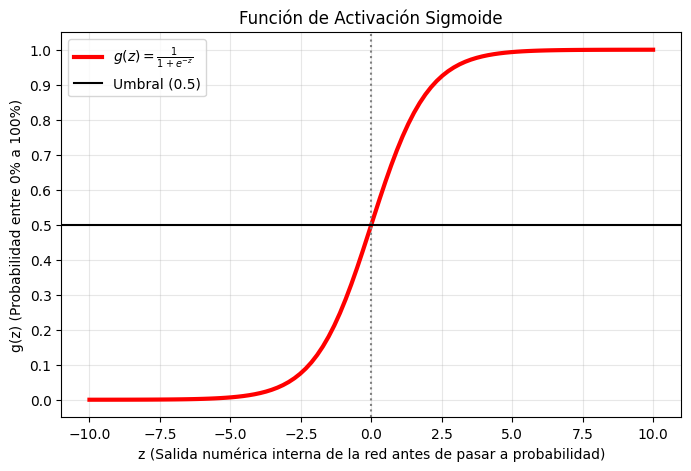

In [6]:
# --- Gráfico demostrativo de cómo funciona una Función SIGMOIDE ---
# Creamos un arreglo de datos que va desde -10 hasta 10, tomando 100 puntos intermedios ordenados de forma lineal
z = np.linspace(-10, 10, 100)

# Aplicamos la fórmula matemática pura de la sigmoide: 1 dividido por (1 mas el número exponencial de E a la menos Zeta)
# En IA, todo número gigante se aplasta a 0.999 y todo número minúsculo se aplasta a 0.001
g_z = 1 / (1 + np.exp(-z))

# Iniciamos el trazado (lienzo) de la figura con tamaño específico: 8 de ancho x 5 de alto
plt.figure(figsize=(8, 5))

# Graficamos la curva sigmoide. Línea dibujada en color rojo con un ancho de 3 puntos.
# "label" es para que aparezca la super ecuación estilo LaTeX al costado como si estuviera escrita a mano
plt.plot(z, g_z, color='red', linewidth=3, label=r'$g(z) = \frac{1}{1 + e^{-z}}$')

# Añadimos la línea horizontal del TEMA BINARIO en 0.5 (color negro, formato línea sólida '-')
# Todo lo que esté gráficamente "arriba" se considerará Clase 1 (Popular) y abajo es Clase 0 (No Popular)
plt.axhline(y=0.5, color='black', linestyle='-', label='Umbral (0.5)')

# Añadimos una tenue línea punteada vertical grisácea exactamente en el cruce de "0" y "0.5" solo por la estética del cruce matemático.
plt.axvline(x=0, color='gray', linestyle=':')

# --- Configuraciones visuales del Gráfico ---
plt.title('Función de Activación Sigmoide')
plt.xlabel('z (Salida numérica interna de la red antes de pasar a probabilidad)')
plt.ylabel('g(z) (Probabilidad entre 0% a 100%)')

# Forzamos los saltos gráficos del eje Y para que salten decímal por decímal [0, 0.1, ... 1.0]
plt.yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

# Mostramos un fondo de cuadrícula cuadriculado translúcido
plt.grid(alpha=0.3)
# Mandamos a activar el cuadro de 'leyenda' donde saldrá el label que preparamos antes.
plt.legend()
# Despliega el bloque entero visual por pantalla.
plt.show()

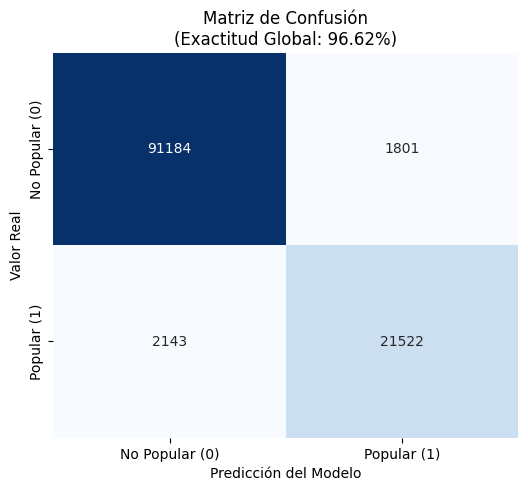

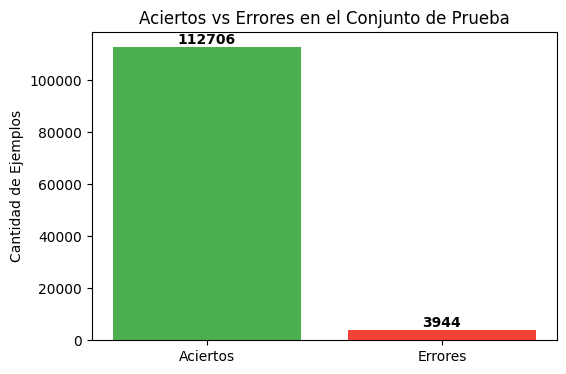

In [7]:
# --- 2.5 Gráfica Visual de Precisión (Matriz de Confusión y Gráfico de Barras) ---
import seaborn as sns
from sklearn.metrics import confusion_matrix

model_bin.eval()
y_true_all = []
y_pred_all = []

# Recolectar todas las predicciones y valores reales del set de prueba
with torch.no_grad():
    for x_b, y_b in dataloader_test_bin:
        probabilidades = model_bin(x_b)
        prediccion_clase = (probabilidades >= 0.5).float()

        y_true_all.extend(y_b.cpu().numpy())
        y_pred_all.extend(prediccion_clase.cpu().numpy())

y_true_all = np.array(y_true_all).flatten()
y_pred_all = np.array(y_pred_all).flatten()

# 1. Matriz de Confusión
cm = confusion_matrix(y_true_all, y_pred_all)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Popular (0)', 'Popular (1)'],
            yticklabels=['No Popular (0)', 'Popular (1)'])
plt.title(f'Matriz de Confusión\n(Exactitud Global: {accuracy:.2f}%)')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.show()

# 2. Gráfico de Barras (Aciertos vs Errores)
aciertos = (y_true_all == y_pred_all).sum()
errores = len(y_true_all) - aciertos

plt.figure(figsize=(6, 4))
plt.bar(['Aciertos', 'Errores'], [aciertos, errores], color=['#4CAF50', '#F44336'])
plt.title('Aciertos vs Errores en el Conjunto de Prueba')
plt.ylabel('Cantidad de Ejemplos')
for i, v in enumerate([aciertos, errores]):
    plt.text(i, v + (max(aciertos, errores)*0.01), str(v), ha='center', fontweight='bold')
plt.show()